# Модуль 20. A/B-тесты и причинность

Ноутбук к [модулю 20](https://drobyshevdev.github.io/lemma/modules/20-ab-tests-and-causality/).

Конфаундер против рандомизации, подглядывание и множественные сравнения — три способа выдумать значимость и защита от каждого. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## 1. Корреляция против причины

Конфаундер $Z$ (активность) влияет и на воздействие $X$ (кому раскатили ленту), и на исход $Y$ (время в приложении). Истинного эффекта воздействия нет. Наблюдательная оценка поймает $Z$ и покажет эффект; рандомизированная — нет.

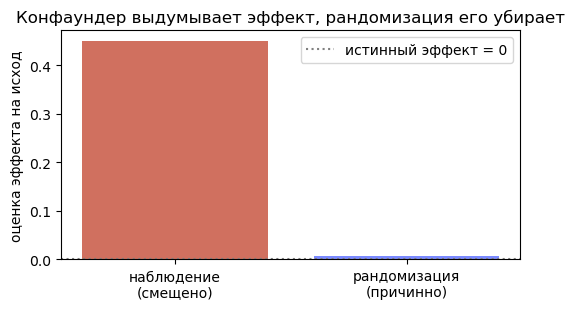

наблюдательная оценка: 0.45 (эффект есть?)   рандомизированная: 0.01 (эффекта нет)


In [2]:
N = 4000
Z = rng.random(N)                                     # конфаундер: активность пользователя
TRUE = 0.0                                            # истинного эффекта воздействия нет

# наблюдение: новую ленту раскатили в основном на активных
X_obs = rng.random(N) < (0.15 + 0.7 * Z)
Y_obs = 2.0 * Z + TRUE * X_obs + rng.normal(0, 0.3, N)
obs_est = Y_obs[X_obs].mean() - Y_obs[~X_obs].mean()

# рандомизация: воздействие назначено монетой, независимо от Z
X_rand = rng.random(N) < 0.5
Y_rand = 2.0 * Z + TRUE * X_rand + rng.normal(0, 0.3, N)
rand_est = Y_rand[X_rand].mean() - Y_rand[~X_rand].mean()

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(["наблюдение\n(смещено)", "рандомизация\n(причинно)"], [obs_est, rand_est],
       color=["#d0705f", "#7b8aff"])
ax.axhline(TRUE, ls=":", color="gray", label="истинный эффект = 0")
ax.set_ylabel("оценка эффекта на исход"); ax.set_title("Конфаундер выдумывает эффект, рандомизация его убирает")
ax.legend(); plt.tight_layout(); plt.show()
print("наблюдательная оценка: %.2f (эффект есть?)   рандомизированная: %.2f (эффекта нет)" % (obs_est, rand_est))

Наблюдение уверенно показывает эффект, которого нет: оно измерило разницу в активности, а не во влиянии ленты. Рандомизация распределила активных по группам поровну — и оценка честно легла у нуля.

**Сломать.** Ослабьте связь воздействия с конфаундером (`0.15 + 0.7*Z -> 0.5`) — наблюдательная оценка приблизится к нулю: чем случайнее назначение, тем меньше смещение.

## 2. Подглядывание рождает ложную значимость

A равно B — эффекта нет. Проверяем по ходу и останавливаемся на первой значимости. Считаем долю ложных побед против честного фиксированного $n$.

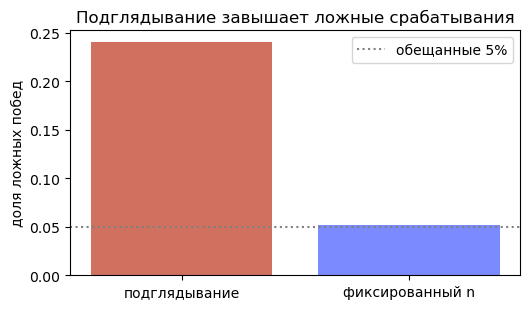

ложные победы -- подглядывание: 24%   фиксированный n: 5%


In [3]:
def trial(peek, blocks=20, block=100, seed=0):
    g = np.random.default_rng(seed)
    a = b = 0.0; sa = sb = 0.0; n = 0
    for _ in range(blocks):
        xa = g.normal(0, 1, block); xb = g.normal(0, 1, block)
        sa += xa.sum(); sb += xb.sum(); n += block
        diff = (sb - sa) / n; se = np.sqrt(2 / n)
        sig = abs(diff) > 1.96 * se
        if peek and sig:
            return True                               # подглядел и остановился на значимости
    return sig                                        # фиксированный n: смотрим только в конце

T = 3000
fp_peek = np.mean([trial(True, seed=s) for s in range(T)])
fp_fixed = np.mean([trial(False, seed=s) for s in range(T)])
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(["подглядывание", "фиксированный n"], [fp_peek, fp_fixed], color=["#d0705f", "#7b8aff"])
ax.axhline(0.05, ls=":", color="gray", label="обещанные 5%")
ax.set_ylabel("доля ложных побед"); ax.set_title("Подглядывание завышает ложные срабатывания")
ax.legend(); plt.tight_layout(); plt.show()
print("ложные победы -- подглядывание: %.0f%%   фиксированный n: %.0f%%" % (100 * fp_peek, 100 * fp_fixed))

Фиксированный $n$ держит обещанные пять процентов. Подглядывание — в разы больше: у разницы много попыток случайно перескочить порог, и одна из них удаётся. Это «остановка по результату» из модуля 1, посчитанная на числах.

**Сломать.** Увеличьте число блоков (`blocks=50`) — доля ложных побед при подглядывании ещё вырастет: чем чаще смотришь, тем вернее выдумаешь эффект.

## 3. Множественные сравнения

Одну метрику воздействие не сдвинуло — проверим двадцать. При двадцати проверках на уровне 0.05 одна ложная значимость ожидается по построению.

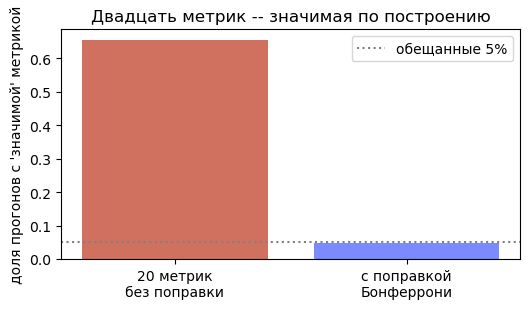

хотя бы одна значима из 20 -- без поправки: 65%   с Бонферрони: 5%


In [4]:
from math import erf, sqrt

T = 3000
def two_sided_p(z): return 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))
def min_p(seed, m=20):
    g = np.random.default_rng(seed); n = 400; ps = []
    for _ in range(m):
        a = g.normal(0, 1, n); b = g.normal(0, 1, n)
        z = (b.mean() - a.mean()) / np.sqrt(2 / n); ps.append(two_sided_p(z))
    return min(ps)
mins = np.array([min_p(s) for s in range(T)])
naive_fp = np.mean(mins < 0.05)                    # хоть одна значима без поправки
bonf_fp = np.mean(mins < 0.05 / 20)                # с поправкой Бонферрони

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(["20 метрик\nбез поправки", "с поправкой\nБонферрони"], [naive_fp, bonf_fp],
       color=["#d0705f", "#7b8aff"])
ax.axhline(0.05, ls=":", color="gray", label="обещанные 5%")
ax.set_ylabel("доля прогонов с 'значимой' метрикой"); ax.set_title("Двадцать метрик -- значимая по построению")
ax.legend(); plt.tight_layout(); plt.show()
print("хотя бы одна значима из 20 -- без поправки: %.0f%%   с Бонферрони: %.0f%%"
      % (100 * naive_fp, 100 * bonf_fp))

Без поправки почти в двух третях прогонов хоть одна из двадцати метрик «значима» — на данных, где эффекта нет вовсе. Поправка Бонферрони (порог 0.05/20) возвращает семейную ошибку к обещанным пяти процентам. Заранее назначенная главная метрика стоит двадцати, выбранных задним числом.

## Что дальше

Часть V закончена. В [части VI](https://drobyshevdev.github.io/lemma/programme/) — агенты: цикл с инструментами и памятью, поиск с проверкой цитат и оценка, где eval — это тест из модуля 7, а регрессия — разница между прогонами, которую вы уже умеете отделять от шума.